In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from idlpy import *
import cartopy.crs as ccrs
import cartopy.feature as cf

IDL 8.7.2 (linux x86_64 m64).
(c) 2019, Harris Geospatial Solutions, Inc.

A new version is available: IDL 8.9
https://www.l3harrisgeospatial.com/Product-Downloads/
 
Licensed for use by: NIWA - National Institute of Water and Atmospheric Research Ltd - Ashley
License: 229483-BUF
Expiration date: 31-Mar-2024


In [2]:
'''
Create vegetation land mask
'''

vege_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/vegetation/1951-2021.nc')
vege_ds['longitude'] = [lon + 360 for lon in vege_ds.longitude.data]

d4pdf_da = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/FWI_HPB_ensMean.nc')

vege_ds = vege_ds.coarsen(latitude=3,longitude=3,boundary='pad').mean()
vege_ds = vege_ds.interp(longitude=d4pdf_da.longitude, latitude=d4pdf_da.latitude, method="linear")

full_lai = vege_ds.lai_hv + vege_ds.lai_lv
full_lai_max = full_lai.max('time')

vege_mask = full_lai_max.where(full_lai_max>3.5)


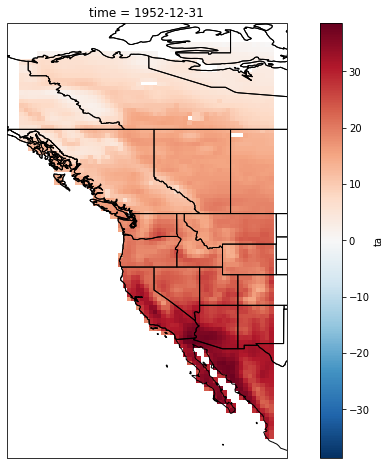

getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec


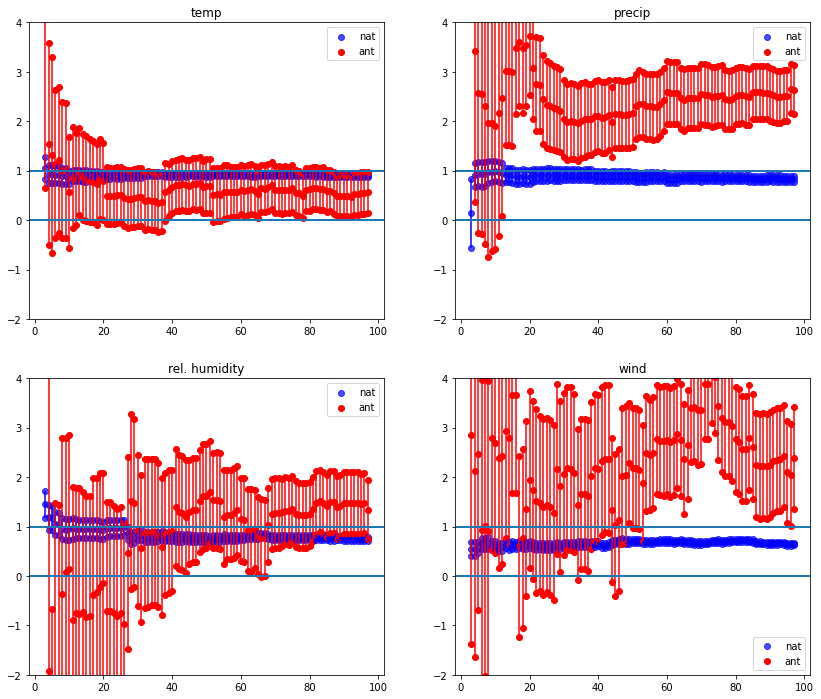

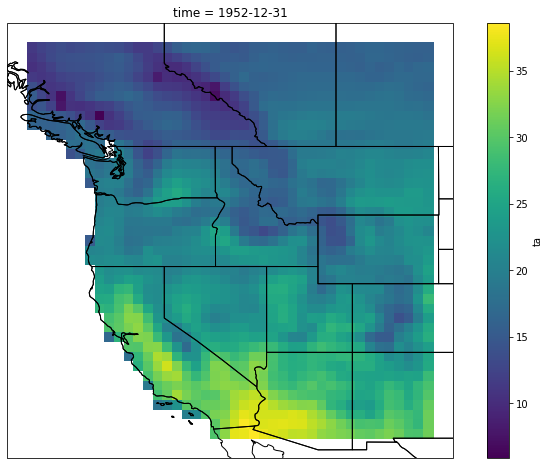

getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec


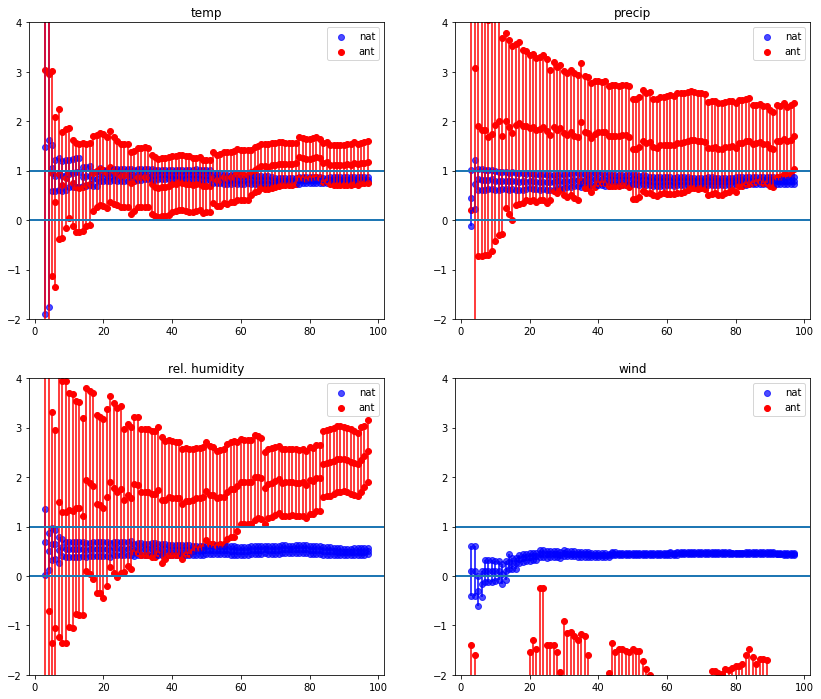

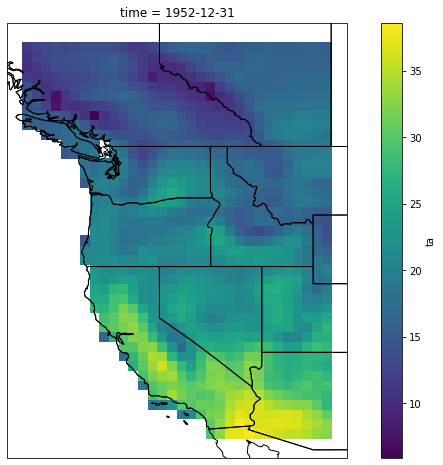

getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec


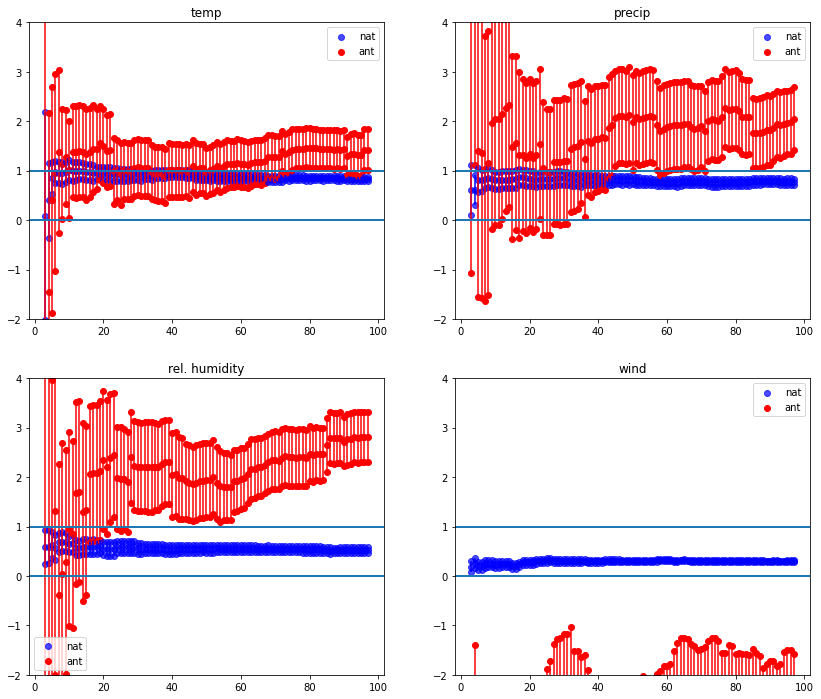

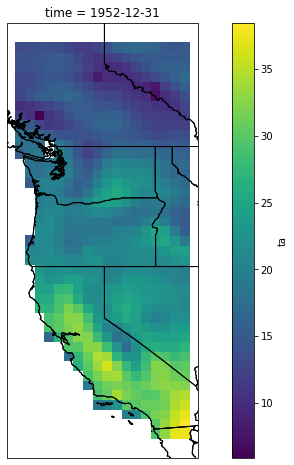

getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec


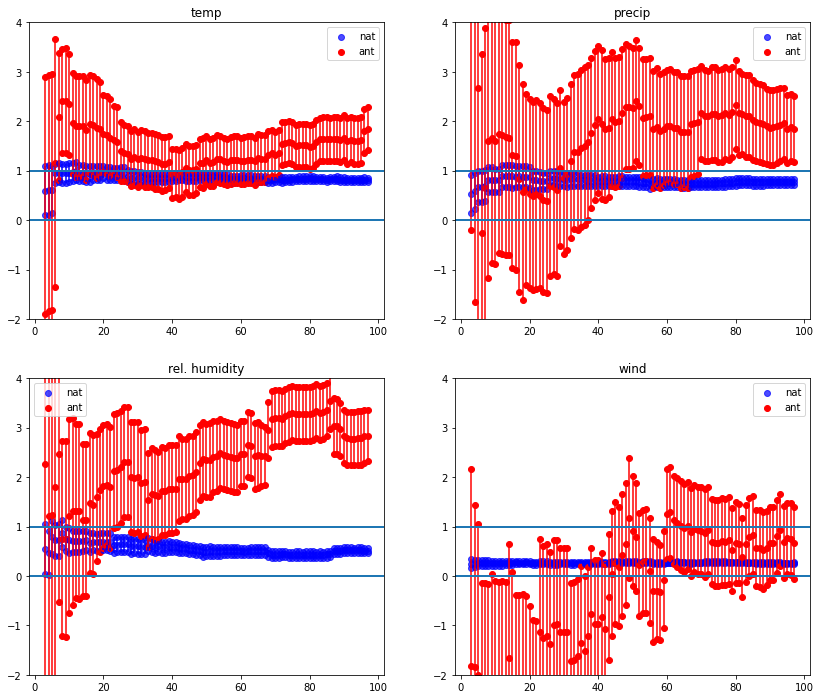

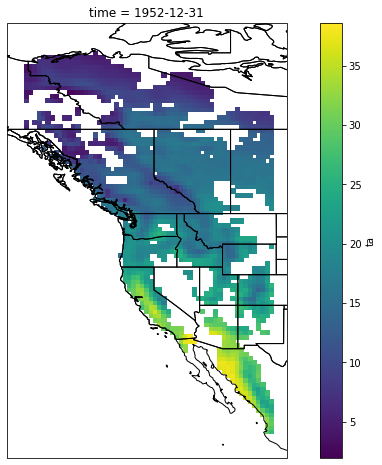

getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec


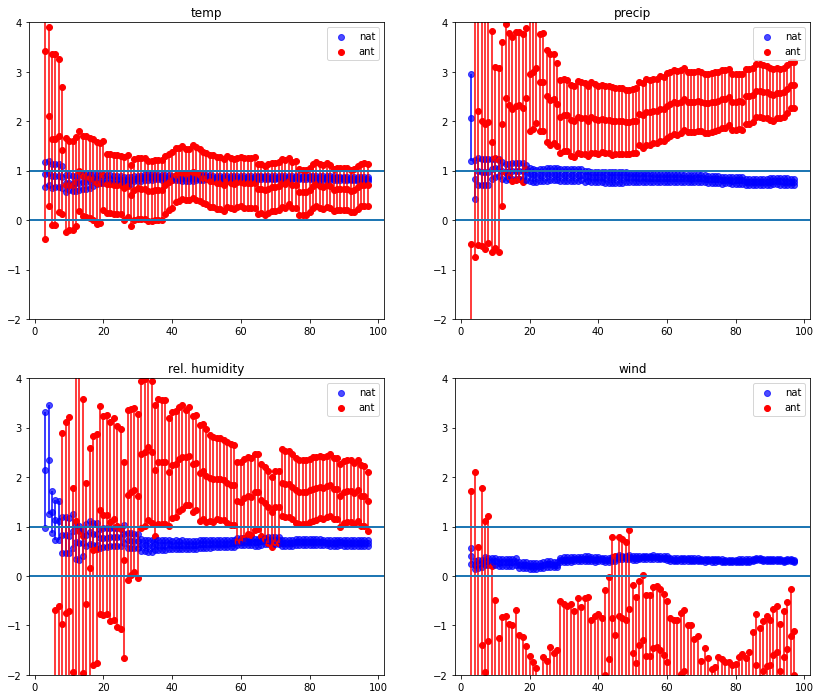

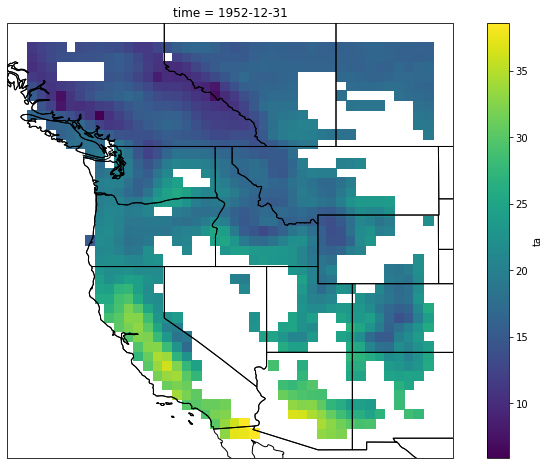

getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec


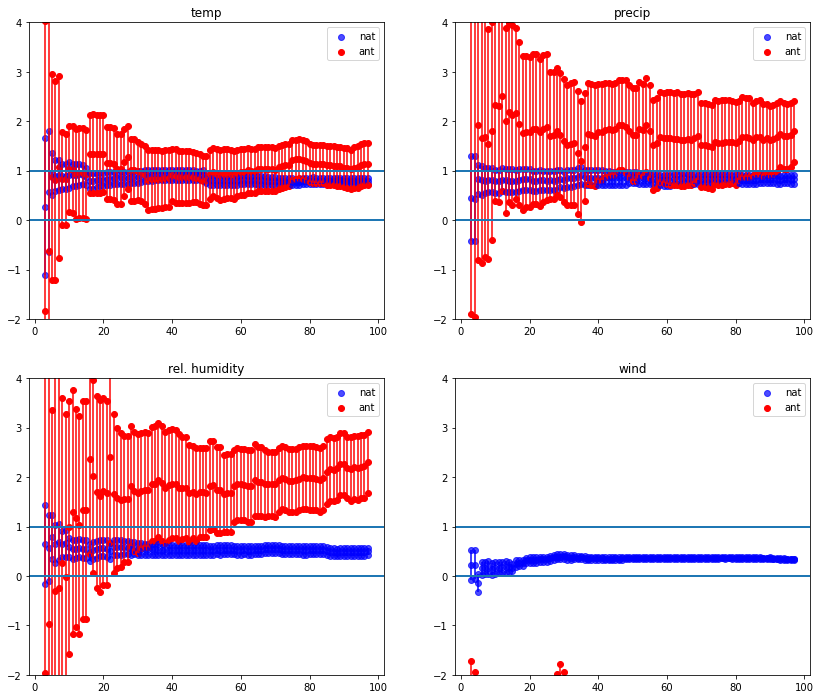

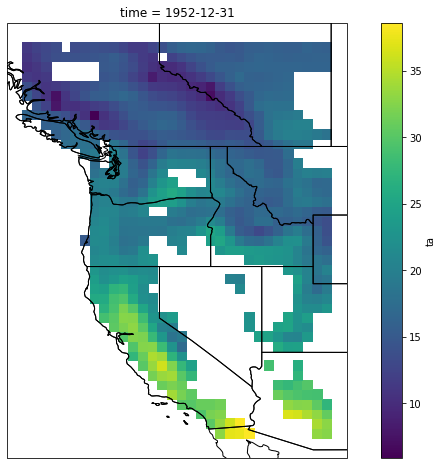

getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec


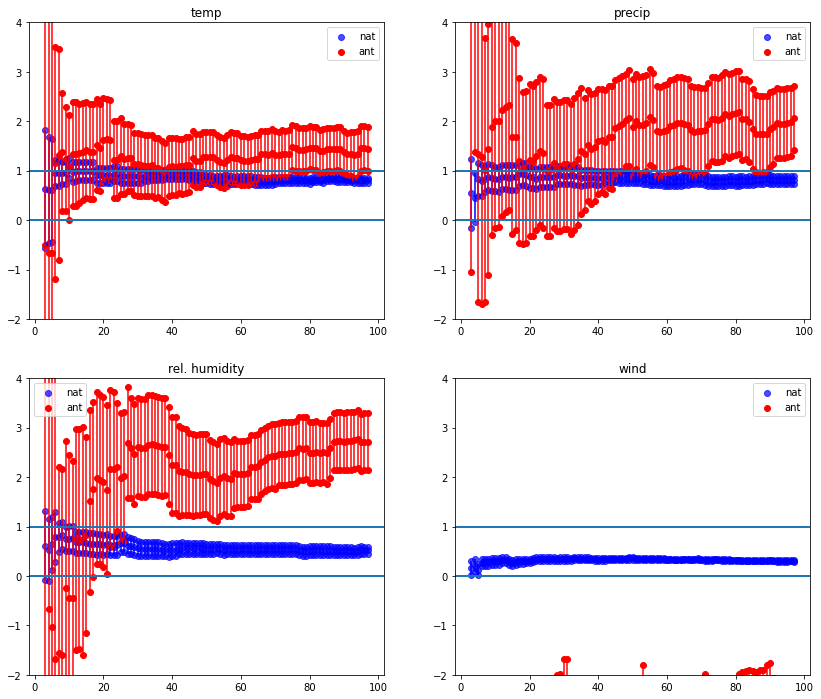

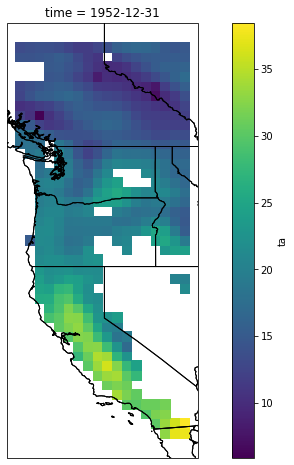

getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec


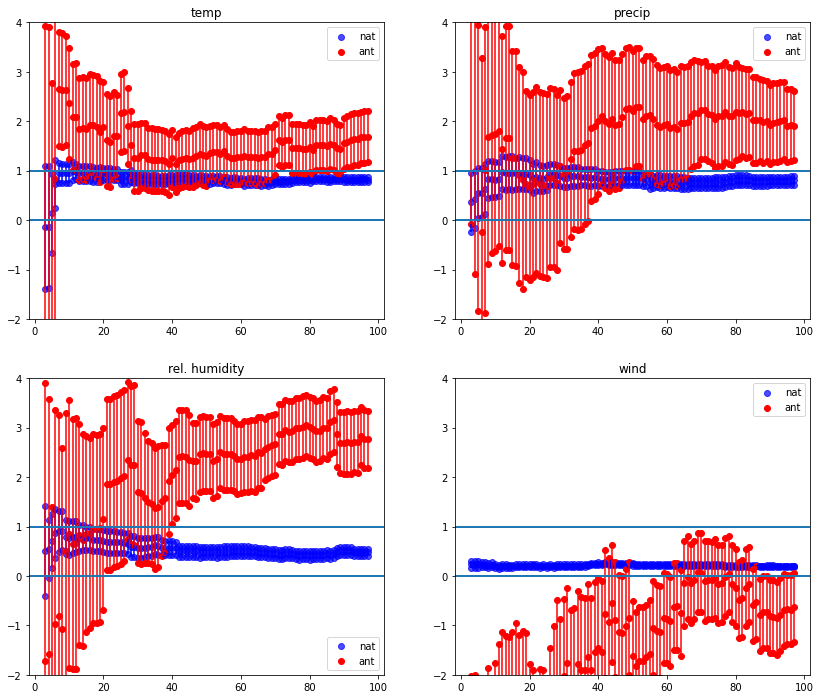

In [26]:
'''
MAIN function for performing optimal fingerprinting using d4pdf and ERA5
'''

var_dict = {'temp':['ta','mx2t'],'precip':['precipi','tp'],'rel. humidity':['rha','min_rh'],'wind':['wind','wind']}

#vege_mask_flag = True
boxes = ['full',[(32,55),(232,256)],[(32,55),(232,250)],[(32,55),(235,245)]]

for vege_mask_flag in [False, True]:
    for box in boxes:
        
        plot_ex_map(box,vege_mask_flag)

        fig,axs = plt.subplots(2,2,figsize=(14,12))
        axs = axs.flatten()
        
        for i,var in enumerate(['temp','precip','rel. humidity','wind']):
            
            ax = axs[i]

            scan_beta_est = fingerprint(var, box, vege_mask_flag)

            for j in range(len(scan_beta_est)):

                beta_est = scan_beta_est[j]
                best_1,low_1,up_1 = beta_est[0][0],beta_est[1][0],beta_est[2][0]
                best_2,low_2,up_2 = beta_est[0][1],beta_est[1][1],beta_est[2][1]

                ax.scatter([j+3]*3,[low_2,best_2,up_2],c='blue',alpha=0.7,label='nat' if j == 0 else '')
                ax.scatter([j+3]*3,[low_1,best_1,up_1],c='red',label='ant' if j == 0 else '')

                ax.vlines(j+3,low_2,up_2,colors=['blue'])
                ax.vlines(j+3,low_1,up_1,colors=['red'])

                ax.axhline(0,-0.5,1.5)
                ax.axhline(1,-0.5,1.5)

            ax.legend()
            ax.set_ylim(-2,4)
            ax.set_title(var)
        
        plt.show()
        plt.close(fig)
        
            

In [23]:
def plot_ex_map(box, vege_mask_flag):
    da = xr.open_dataset('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/inputs/FWI_inputs_HPB_ensMean.nc')['ta']
    da = da.rename({'lat':'latitude','lon':'longitude'})
    
    if box != 'full':
        da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
    if vege_mask_flag:
        da = da.where(vege_mask>0)

    fig, axs = plt.subplots(1, 1, figsize=(12,8),subplot_kw=dict(projection=ccrs.PlateCarree()))

    da.isel(time=1).plot(ax=axs,transform=ccrs.PlateCarree())
    axs.coastlines()  # cartopy function
    axs.add_feature(cf.BORDERS)
    axs.add_feature(cf.STATES)

    plt.show()
    plt.close(fig)

            

In [14]:
def fingerprint(var, box, vege_mask_flag):

    IDL.retall

    print('getting ALL mean and noise')
    all_ens_mean,noise_all = get_mean_and_noise(var, 'HPB', box, vege_mask_flag)
    print('getting NAT mean and noise')
    nat_ens_mean,noise_nat = get_mean_and_noise(var, 'HPB_NAT', box, vege_mask_flag)

    print('getting obs')
    data_obs = get_obs_data(var, box, vege_mask_flag)
    print('got obs')
    data_scen = np.array([all_ens_mean,nat_ens_mean])

    data_noise_1 = np.concatenate((noise_all[:50],noise_nat[:50]))
    data_noise_2 = np.concatenate((noise_all[50:],noise_nat[50:]))

    print('got arrays')

    trunc = np.array([i for i in range(3,98)])

    IDL.data_obs = data_obs
    IDL.data_scen = data_scen
    IDL.data_noise_1 = data_noise_1
    IDL.data_noise_2 = data_noise_2
    IDL.trunc = trunc
    IDL.scan_beta_est = []

    print('running gendetec')
    IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, scan_resid_sumsq=scan_resid_sumsq, \
            data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, scan_beta_est=scan_beta_est")

    scan_beta_est = IDL.scan_beta_est

    da.close()
    
    return scan_beta_est

In [19]:
def get_obs_data(var, box, vege_mask_flag):
            
    da = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/FWI_inputs_6month_fire_season_model_grid.nc')[var_dict[var][1]]

    if box != 'full':
        da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

    if vege_mask_flag:
        da = da.where(vege_mask>0)
        
    da = da.sel(time=slice("1951","2021"))
    da = da.stack(pixel=("latitude", "longitude"))
    da = da.dropna("pixel", how="all")        
    
    array = da.values.flatten()
    
    del da
    
    return(array)


In [20]:
def get_mean_and_noise(var, scen, box, vege_mask_flag):
    
    era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/FWI_6month_fire_season_model_grid.nc')

    ens_mean = xr.open_dataset('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/inputs/FWI_inputs_'+scen+'_ensMean.nc')[var_dict[var][0]]
    ens_mean = ens_mean.rename({'lat':'latitude','lon':'longitude'})
    
    if box != 'full':
        ens_mean = ens_mean.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

    if vege_mask_flag:
        ens_mean = ens_mean.where(vege_mask>0)
        
    ens_mean = ens_mean.sel(time=slice("1951","2021"))
    ens_mean = ens_mean.where(~era5_da.isnull())
    
    noise = []
    for ens_mem in range(1,101):
        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

        mem_da = xr.open_dataset('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/inputs/FWI_inputs_'+scen+'_m'+number+'.nc')[var_dict[var][0]]
        mem_da = mem_da.rename({'lat':'latitude','lon':'longitude'})
        
        if box != 'full':
            mem_da = mem_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

        if vege_mask_flag:
            mem_da = mem_da.where(vege_mask>0)

        mem_da = mem_da.sel(time=slice("1951","2021"))
        mem_da = mem_da.where(~era5_da.isnull())

        diff = mem_da - ens_mean

        diff = diff.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
        diff = diff.dropna("pixel", how="all")# Drop the pixels that only have NA values.
                
        diff_array = diff.values.flatten()
        noise.append(diff_array)
        
        del mem_da
        del diff_array

    ens_mean = ens_mean.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
    ens_mean = ens_mean.dropna("pixel", how="all")# Drop the pixels that only have NA values.
    ens_mean_array = ens_mean.values.flatten()

    del ens_mean
    
    return((ens_mean_array, np.array(noise)))


In [17]:
def plot_result(scan_beta_est, ax):

    for j in range(len(scan_beta_est)):

        beta_est = scan_beta_est[j]
        best_1,low_1,up_1 = beta_est[0][0],beta_est[1][0],beta_est[2][0]
        best_2,low_2,up_2 = beta_est[0][1],beta_est[1][1],beta_est[2][1]

        ax.scatter([j+3]*3,[low_2,best_2,up_2],c='blue',alpha=0.7,label='nat' if j == 0 else '')
        ax.scatter([j+3]*3,[low_1,best_1,up_1],c='red',label='ant' if j == 0 else '')

        ax.vlines(j+3,low_2,up_2,colors=['blue'])
        ax.vlines(j+3,low_1,up_1,colors=['red'])

        ax.axhline(0,-0.5,1.5)
        ax.axhline(1,-0.5,1.5)

    ax.legend()
    ax.set_ylim(-1,4)

    #plt.title('ERA5/d4pdf 6month fire season FWI OF (1951-2021)')
    #plt.savefig('/nesi/project/niwa00015/queenle/plots/fire/era5_fingerprinting/FWI/6month_fire_season/'+resample_interval+'/result.png')
    #plt.show()
    #plt.close(fig)
    